# K-Means Clustering
K-Means clustering is an unsupervised machine learning algorithm used to group similar data points into clusters. The algorithm works by initializing a set of centroids, assigning each data point to the nearest centroid, and then updating the centroids based on the assigned points. This process is repeated until convergence, where the centroids no longer change significantly.

### Cluster
Cluster is a collection of data points that are similar to each other within the same group and dissimilar to those in other groups.
1. Intra-cluster similarity: High similarity between data points within the same cluster.
2. Inter-cluster dissimilarity: Low dissimilarity between data points in different clusters.

### K-Means
K-Means is a popular clustering algorithm that partitions data into K clusters based on feature similarity. The algorithm follows these steps:
1. Initialization: Randomly select K initial centroids(means).
2. Assignment: Assign each data point to the nearest centroid based on a distance metric (e.g., Euclidean distance).
3. Update: Recalculate the centroids as the mean of all data points assigned to each cluster.
4. Repeat: Repeat the assignment and update steps until convergence (i.e., centroids do not change significantly).

### Hyperparameters
1. Number of Clusters (K): The number of clusters to form. If K is too small, clusters may be too broad; if K is too large, clusters may be too specific.
2. Initialization Method: The method used to initialize the centroids (e.g., random initialization, K-Means++). K-Means++ is often preferred as it helps in better convergence.
3. Maximum Iterations: The maximum number of iterations to run the algorithm. This prevents infinite loops in case of non-convergence.
4. Tolerance: A threshold to determine convergence based on the change in centroids. If the change is less than the tolerance, the algorithm stops.
5. Distance Metric: The metric used to measure the distance between data points and centroids (e.g., Euclidean, Manhattan). Euclidean distance is commonly used in K-Means.

## Elbow Method
The Elbow Method is a technique used to determine the optimal number of clusters (K) in K-Means clustering. It involves plotting the calculated variance (or inertia) against the number of clusters and looking for an `elbow` point where the rate of decrease in inertia slows down significantly. This point indicates a good balance between cluster compactness and simplicity. 

#### Inertia
Inertia is a measure of how tightly the data points in a cluster are grouped around the centroid. It is calculated as the sum of squared distances between each data point and its assigned centroid. Lower inertia values indicate more compact clusters meaning that the data points are closer to their respective centroids.

```math
Inertia/WCSS = \sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2
```
Where:
- $K$: Number of clusters
- $C_i$: Set of data points in cluster $i$
- $x$: A data point in cluster $C_i$
- $\mu_i$: Centroid of cluster $i$
- WCSS: Within-Cluster Sum of Squares

#### Scaling
Scaling the data before applying K-Means clustering is important because K-Means relies on distance calculations (e.g., Euclidean distance) to assign data points to clusters. If the features have different scales, those with larger ranges can disproportionately influence the distance calculations, leading to biased clustering results. Scaling ensures that all features contribute equally to the distance metric, resulting in more meaningful and accurate clusters. Standardization (z-score normalization) and Min-Max scaling are common techniques used to scale data before applying K-Means clustering.

#### K-means++
K-Means++ is an improved initialization method for the K-Means clustering algorithm. It aims to select initial centroids that are more spread out, which can lead to better convergence and improved clustering results. The K-Means++ algorithm follows these steps for initialization:
1. Randomly select the first centroid from the data points.
2. For each subsequent centroid, calculate the distance between each data point and the nearest already chosen centroid.
3. Select the next centroid from the data points with a probability proportional to the square of the distance calculated in the previous step.Points that are far away from existing centroids have a much higher chance of being selected as the next center.

This approach helps to ensure that the initial centroids are well-distributed across the data space, reducing the likelihood of poor clustering results due to suboptimal initialization.

#### Silhouette Score
The Silhouette Score is a metric used to evaluate the quality of clustering results. It measures how similar an object is to its own cluster compared to other clusters. The score ranges from -1 to 1, where a value close to 1 indicates that the data point is well clustered, a value of 0 indicates that the data point is on or very close to the decision boundary between two neighboring clusters, and a value close to -1 indicates that the data point may have been assigned to the wrong cluster.\
Common interpretations of the Silhouette Score are:
- Above 0.5: Strong clustering structure
- Between 0.2 and 0.4: Overlapping clusters
- Near 0: Useless clustering structure
- Below 0: Incorrect clustering

The Silhouette Score for a single data point is calculated using the formula:
```math
s(i) = \frac{b(i) - a(i)}{max(a(i), b(i))}
```
Where:
- $s(i)$: Silhouette Score for data point $i$
- $a(i)$: Average distance between data point $i$ and all other points in its own cluster (intra-cluster distance)
- $b(i)$: Average distance between data point $i$ and all points in the nearest cluster (inter-cluster distance)

The overall Silhouette Score for the clustering solution is the average of the Silhouette Scores for all data points.

##### Example
Let a dataset of 7 samples with 2 features be given below:
| Sample | Feature 1 | Feature 2 |
|--------|-----------|-----------|
|   1    |    1.0    |    2.0    |
|   2    |    1.5    |    1.8   |
|   3    |    5.0    |    8.0   |
|   4    |    8.0    |    8.0   |
|   5    |    1.0    |    0.6   |
|   6    |    9.0    |    11.0  |
|   7    |    8.0    |    2.0   | 

1. Initialize K=3 centroids randomly:
   - Centroid A: $(1.0, 2.0)$
   - Centroid B: $(5.0, 8.0)$
   - Centroid C: $(8.0, 2.0)$
2. Assign each sample to the nearest centroid based on Euclidean distance. Use a table where each row represents a sample and each column represents the distance to a centroid. Assign the sample to the cluster of the nearest centroid. (using euclidean distance formula: $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$ )

    | Sample | Distance to CA | Distance to CB | Distance to CC | Assigned Cluster |
    |--------|----------------|----------------|----------------|------------------|
    |   1    |      0.0       |      7.07      |      7.0       |        A         |
    |   2    |      0.54      |      6.10      |      6.5       |        A         |
    |   3    |      7.21      |      0.0       |      6.0       |        B         |
    |   4    |      9.22      |      3.00       |      6.0       |        B         |
    |   5    |      1.4       |      8.06      |      7.0       |        A         |
    |   6    |     11.40      |      5.0       |      3.16      |        C         |
    |   7    |      7.0       |      6.0       |      0.0       |        C         |
 
    So, the clusters are:
    - Cluster A: Samples ${1, 2, 5}$
    - Cluster B: Samples ${3, 4}$
    - Cluster C: Samples ${6, 7}$
3. Update centroids by calculating the mean of all samples assigned to each cluster:
   - New Centroid A: $(\frac{1.0 + 1.5 + 1.0}{3}, \frac{2.0 + 1.8 + 0.6}{3}) = (1.17, 1.47)$
   - New Centroid B: $(\frac{5.0 + 8.0}{2}, \frac{8.0 + 8.0}{2}) = (6.5, 8.0)$
   - New Centroid C: $(\frac{9.0 + 8.0}{2}, \frac{11.0 + 2.0}{2}) = (8.5, 6.5)$
4. Repeat the assignment and update the samples clusters.
    | Sample | Distance to CA | Distance to CB | Distance to CC | Assigned Cluster |
    |--------|----------------|----------------|----------------|------------------|
    |   1    |      0.54      |      7.21      |      5.66      |        A         |
    |   2    |      0.36      |      6.65      |      5.13      |        A         |
    |   3    |      7.21      |      0.0       |      3.61      |        B         |
    |   4    |      9.22      |      1.50       |      3.61      |        B         |
    |   5    |      1.4       |      8.06      |      6.5       |        A         |
    |   6    |     11.40      |      5.0       |      4.24      |        C         |
    |   7    |      7.0       |      6.0       |      4.24      |        C         |

    So, the clusters remain the same:
    - Cluster A: Samples ${1, 2, 5}$
    - Cluster B: Samples ${3, 4}$
    - Cluster C: Samples ${6, 7}$
5. Since the clusters did not change(convergence), the algorithm has converged. The final clusters are:
    - Cluster A: Samples ${1, 2, 5}$
    - Cluster B: Samples ${3, 4}$
    - Cluster C: Samples ${6, 7}$
6. The same process will be repeated for another k value like k=2, k=4 etc. and the inertia values will be calculated for each k. Finally, the inertia values will be plotted against the k values to find the elbow point which indicates the optimal number of clusters.

### Limitations of K-Means
- Requires choosing k manually
- Sensitive to feature scaling
- Fails with non-spherical clusters
- Sensitive to outliers
- Distance-based, not density-based
- Cluster can not be trusted blindly

In [7]:
# Implementaion of K-Means Clustering Algorithm
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

url = "https://github.com/kennedykwangari/Mall-Customer-Segmentation-Data/blob/master/Mall_Customers.csv?raw=true"
data = pd.read_csv(url)

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [17]:
X = data.iloc[:, [2, 3, 4]].values     # Using 'Age, Annual Income' and 'Spending Score' columns for clustering

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Finding Optimal k (Elbow Method)
inertia_values = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(
    n_clusters=k, 
    init='k-means++',
    max_iter=300, 
    random_state=42)

    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

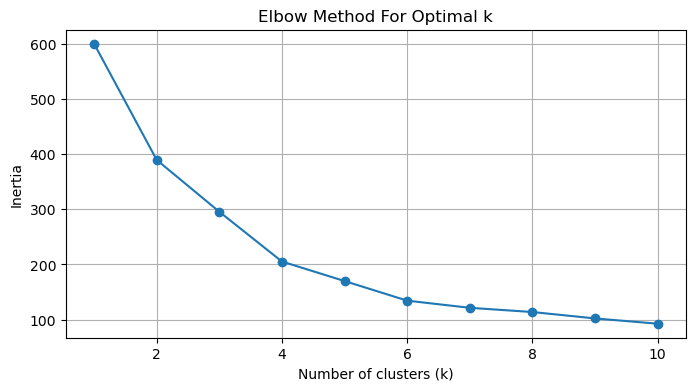

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# From the elbow plot, let's assume the optimal k is 4

In [35]:
kmeans = KMeans(
    n_clusters=4, 
    init='k-means++',
    max_iter=300, 
    random_state=42)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [51]:
centers = kmeans.cluster_centers_
centers

array([[ 1.08616125, -0.49056525, -0.39717443],
       [-0.42880597,  0.97484722,  1.21608539],
       [-0.96249203, -0.78476346,  0.39202966],
       [ 0.03720536,  0.99011499, -1.18875705]])

In [37]:
y_kmeans = kmeans.predict(X_scaled)
data['Cluster'] = y_kmeans

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


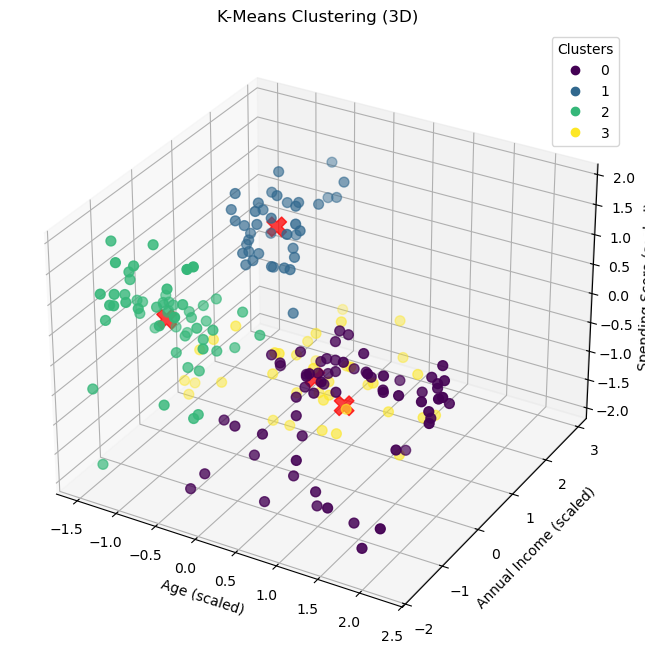

In [55]:
plt.figure(figsize=(12, 8))
ax = plt.axes(projection='3d')
scatter = ax.scatter3D(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=y_kmeans, s=50, cmap='viridis')
ax.scatter3D(centers[:, 0], centers[:, 1], centers[:, 2], c='red', s=200, alpha=0.75, marker='X')
ax.set_title("K-Means Clustering (3D)")
ax.set_xlabel('Age (scaled)')
ax.set_ylabel('Annual Income (scaled)')
ax.set_zlabel('Spending Score (scaled)')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [57]:
score = silhouette_score(X_scaled, y_kmeans)
print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.4040
